# Notebook 16 — Entraînement Modèle Final (LinearSVC + Calibration)

**Objectif :** Entraîner un meilleur modèle sur le dataset logistique français généré en notebook 15.

**Améliorations par rapport à l'ancien modèle :**
- LinearSVC (meilleur que LR pour la classification de texte)
- CalibratedClassifierCV (probabilités bien calibrées, plus de 20-40%)
- TF-IDF avec ngrams jusqu'à 3-grammes et 15 000 features
- Dataset logistique réel au lieu de traductions de réclamations financières américaines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from pathlib import Path

DATA_PATH = Path('../data/processed/reclamations_logistics_fr.csv')
print("Packages chargés OK")

C:\Users\suki\AppData\Local\Temp\ipykernel_27188\2808998480.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Packages chargés OK


## 1. Chargement et exploration des données

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Total : {len(df)} exemples")
print(f"Colonnes : {df.columns.tolist()}")
print("\nDistribution des catégories :")
print(df['categorie'].value_counts())
print(f"\nTaux le plus déséquilibré : {df['categorie'].value_counts().min() / df['categorie'].value_counts().max():.2%}")
df.head()

Total : 2462 exemples
Colonnes : ['texte', 'categorie']

Distribution des catégories :
categorie
retard_livraison         446
mauvaise_qualite         415
produit_casse            411
probleme_transport       353
erreur_picking           318
article_manquant         298
erreur_administrative    221
Name: count, dtype: int64

Taux le plus déséquilibré : 49.55%


,texte,categorie
0,Le enceinte est arrivé en pièces détachées sui...,produit_casse
1,Problème avec le transporteur DHL : mon colis ...,probleme_transport
2,La couture de mon appareil électroménager s'es...,mauvaise_qualite
3,Produit incorrect reçu : j'attendais des lunet...,erreur_picking
4,Le bon de livraison indique un pull gris S mai...,erreur_picking


In [3]:
# Vérification des données nulles
print("Valeurs nulles :", df.isnull().sum().to_dict())
df = df.dropna(subset=['texte', 'categorie'])
df = df[df['texte'].str.strip().str.len() > 0]
print(f"Après nettoyage : {len(df)} exemples")

Valeurs nulles : {'texte': 0, 'categorie': 0}
Après nettoyage : 2462 exemples


## 2. Préparation des données

In [4]:
# Utiliser la colonne texte (brute) — le TF-IDF gère la vectorisation
# On NE réapplique PAS le preprocessing spaCy ici car c'est lent
# et le modèle pipeline le fait déjà en production

X = df['texte'].values
y = df['categorie'].values

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entraînement : {len(X_train)} exemples")
print(f"Test          : {len(X_test)} exemples")
print("\nDistribution train :")
pd.Series(y_train).value_counts()

Entraînement : 1969 exemples
Test          : 493 exemples

Distribution train :


retard_livraison         357
mauvaise_qualite         332
produit_casse            329
probleme_transport       282
erreur_picking           254
article_manquant         238
erreur_administrative    177
Name: count, dtype: int64

## 3. Définition des pipelines

In [5]:
# TF-IDF amélioré
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 3),      # unigrams, bigrams, trigrams
    sublinear_tf=True,       # log(tf) au lieu de tf
    min_df=1,                # garder les mots rares (petit dataset)
    max_df=0.95,
    analyzer='word',
    strip_accents='unicode',
    lowercase=True,
)

# Modèle 1 : LinearSVC calibré (recommandé)
svc = LinearSVC(C=1.0, max_iter=5000, class_weight='balanced')
pipeline_svc = Pipeline([
    ('tfidf', tfidf),
    ('clf', CalibratedClassifierCV(svc, cv=5))
])

# Modèle 2 : LogisticRegression tuné (pour comparaison)
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000, ngram_range=(1, 3),
        sublinear_tf=True, min_df=1, max_df=0.95,
        strip_accents='unicode', lowercase=True
    )),
    ('clf', LogisticRegression(C=5.0, max_iter=2000, class_weight='balanced', solver='lbfgs', multi_class='auto'))
])

print("Pipelines définis")

Pipelines définis


## 4. Entraînement et évaluation

In [6]:
# Entraîner LinearSVC calibré
print("Entraînement LinearSVC calibré...")
pipeline_svc.fit(X_train, y_train)
y_pred_svc = pipeline_svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc, average='weighted')
print(f"LinearSVC - Accuracy: {acc_svc:.4f} | F1 weighted: {f1_svc:.4f}")

Entraînement LinearSVC calibré...


C:\Users\suki\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\suki\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\suki\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\suki\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dua

LinearSVC - Accuracy: 0.8763 | F1 weighted: 0.8762


In [7]:
# Entraîner LogisticRegression
print("Entraînement LogisticRegression tuné...")
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
print(f"LogisticRegression - Accuracy: {acc_lr:.4f} | F1 weighted: {f1_lr:.4f}")

Entraînement LogisticRegression tuné...
LogisticRegression - Accuracy: 0.8621 | F1 weighted: 0.8617


In [8]:
# Comparaison
print("\n=== COMPARAISON ===")
print(f"LinearSVC calibré  : Accuracy={acc_svc:.2%} | F1={f1_svc:.2%}")
print(f"LogisticRegression : Accuracy={acc_lr:.2%} | F1={f1_lr:.2%}")
print(f"Ancien modèle (LR) : Accuracy=~78%")

meilleur_pipeline = pipeline_svc if acc_svc >= acc_lr else pipeline_lr
meilleur_nom = "LinearSVC" if acc_svc >= acc_lr else "LogisticRegression"
print(f"\nMeilleur modèle : {meilleur_nom}")


=== COMPARAISON ===
LinearSVC calibré  : Accuracy=87.63% | F1=87.62%
LogisticRegression : Accuracy=86.21% | F1=86.17%
Ancien modèle (LR) : Accuracy=~78%

Meilleur modèle : LinearSVC


## 5. Rapport détaillé par catégorie

In [9]:
y_pred = meilleur_pipeline.predict(X_test)

print("=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

=== RAPPORT DE CLASSIFICATION ===
                       precision    recall  f1-score   support

     article_manquant       1.00      0.98      0.99        60
erreur_administrative       0.80      0.91      0.85        44
       erreur_picking       0.98      0.91      0.94        64
     mauvaise_qualite       0.83      0.92      0.87        83
   probleme_transport       0.88      0.90      0.89        71
        produit_casse       0.82      0.82      0.82        82
     retard_livraison       0.87      0.76      0.81        89

             accuracy                           0.88       493
            macro avg       0.88      0.89      0.88       493
         weighted avg       0.88      0.88      0.88       493



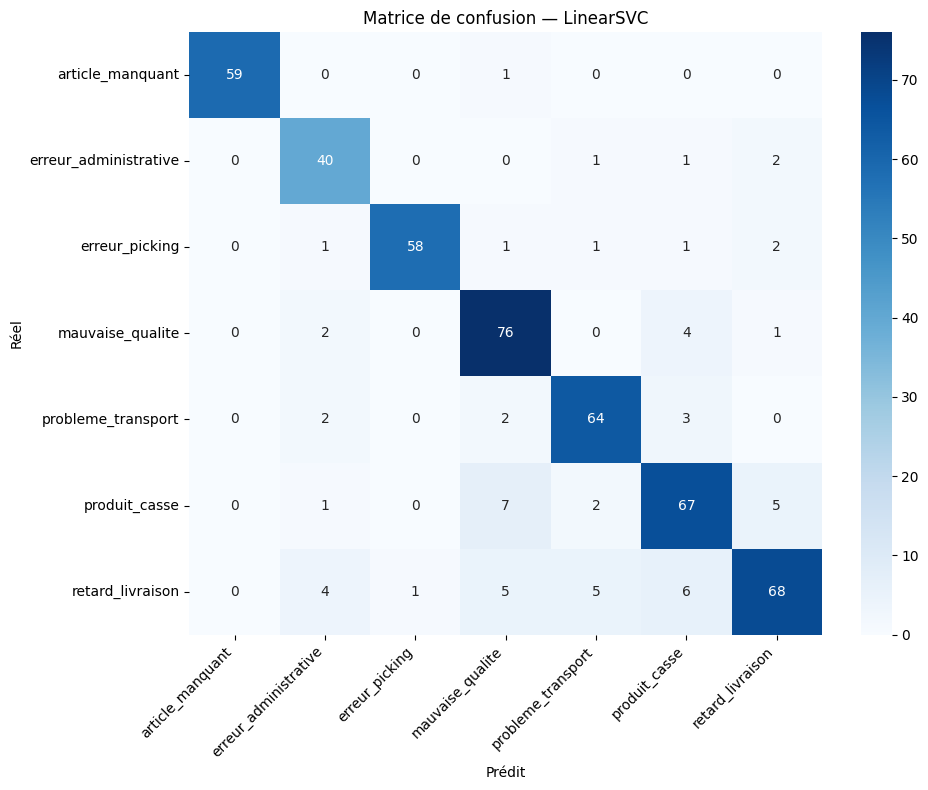

Matrice sauvegardée


In [10]:
# Matrice de confusion
labels = sorted(set(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title(f'Matrice de confusion — {meilleur_nom}')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrix_v2.png', dpi=150)
plt.show()
print("Matrice sauvegardée")

## 6. Vérification des probabilités (calibration)

Confiance moyenne sur le test set : 82.95%
Confiance médiane                : 94.55%
Confiance min                    : 29.01%
% prédictions > 70% confiance    : 76.67%
% prédictions > 50% confiance    : 90.06%
% prédictions < 40% confiance    : 2.64%


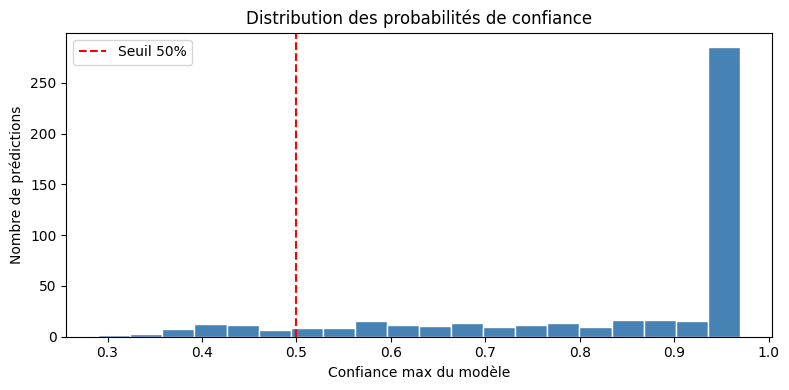

In [11]:
# Vérifier que les probabilités sont bien calibrées (pas 20-40% comme avant)
probas = meilleur_pipeline.predict_proba(X_test)
max_probas = probas.max(axis=1)

print(f"Confiance moyenne sur le test set : {max_probas.mean():.2%}")
print(f"Confiance médiane                : {np.median(max_probas):.2%}")
print(f"Confiance min                    : {max_probas.min():.2%}")
print(f"% prédictions > 70% confiance    : {(max_probas > 0.7).mean():.2%}")
print(f"% prédictions > 50% confiance    : {(max_probas > 0.5).mean():.2%}")
print(f"% prédictions < 40% confiance    : {(max_probas < 0.4).mean():.2%}")

plt.figure(figsize=(8, 4))
plt.hist(max_probas, bins=20, color='steelblue', edgecolor='white')
plt.axvline(0.5, color='red', linestyle='--', label='Seuil 50%')
plt.title('Distribution des probabilités de confiance')
plt.xlabel('Confiance max du modèle')
plt.ylabel('Nombre de prédictions')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Test sur des réclamations réelles

In [12]:
tests = [
    ("Ma commande n'est pas arrivée depuis 10 jours, où est mon colis ?", "retard_livraison"),
    ("J'ai reçu mon téléphone complètement cassé, l'écran est fissuré.", "produit_casse"),
    ("J'ai commandé une chemise bleue taille M mais j'ai reçu un pantalon rouge.", "erreur_picking"),
    ("Mon colis est arrivé mais il manque le chargeur.", "article_manquant"),
    ("Le produit est de très mauvaise qualité, il s'est cassé après 2 jours.", "mauvaise_qualite"),
    ("Le livreur a tenté de livrer mais j'étais chez moi, maintenant mon colis est perdu.", "probleme_transport"),
    ("J'ai été débité deux fois pour la même commande.", "erreur_administrative"),
    # Textes courts
    ("Colis cassé !", "produit_casse"),
    ("Retard livraison", "retard_livraison"),
    ("Article manquant", "article_manquant"),
]

print(f"{'Texte':<55} {'Attendu':<22} {'Prédit':<22} {'Conf':>6} {'OK?'}")
print("-" * 115)
for texte, attendu in tests:
    pred = meilleur_pipeline.predict([texte])[0]
    proba = meilleur_pipeline.predict_proba([texte])[0]
    conf = max(proba)
    ok = "✓" if pred == attendu else "✗"
    print(f"{texte[:53]:<55} {attendu:<22} {pred:<22} {conf:>5.0%} {ok}")

Texte                                                   Attendu                Prédit                   Conf OK?
-------------------------------------------------------------------------------------------------------------------
Ma commande n'est pas arrivée depuis 10 jours, où est   retard_livraison       retard_livraison         68% ✓
J'ai reçu mon téléphone complètement cassé, l'écran e   produit_casse          produit_casse            93% ✓
J'ai commandé une chemise bleue taille M mais j'ai re   erreur_picking         erreur_picking           96% ✓
Mon colis est arrivé mais il manque le chargeur.        article_manquant       article_manquant         48% ✓
Le produit est de très mauvaise qualité, il s'est cas   mauvaise_qualite       mauvaise_qualite         76% ✓
Le livreur a tenté de livrer mais j'étais chez moi, m   probleme_transport     probleme_transport       94% ✓
J'ai été débité deux fois pour la même commande.        erreur_administrative  erreur_administrative    95% ✓
C

## 8. Validation croisée (robustesse)

In [13]:
print("Validation croisée 5-fold sur LinearSVC calibré...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Note: cross_val_score sur un CalibratedClassifierCV peut être lent
# On utilise le pipeline complet
scores = cross_val_score(pipeline_svc, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Scores par fold : {[f'{s:.2%}' for s in scores]}")
print(f"Moyenne : {scores.mean():.2%} ± {scores.std():.2%}")

Validation croisée 5-fold sur LinearSVC calibré...
Scores par fold : ['88.84%', '90.47%', '88.62%', '92.28%', '88.82%']
Moyenne : 89.81% ± 1.40%


In [14]:
print("\n=== RÉSUMÉ FINAL ===")
print(f"Modèle sélectionné : {meilleur_nom}")
print(f"Accuracy test      : {accuracy_score(y_test, y_pred):.2%}")
print(f"F1 weighted        : {f1_score(y_test, y_pred, average='weighted'):.2%}")
print(f"CV accuracy        : {scores.mean():.2%} ± {scores.std():.2%}")
print(f"Confiance moyenne  : {max_probas.mean():.2%}")
print("\nPipeline prêt pour la sauvegarde (notebook 17)")


=== RÉSUMÉ FINAL ===
Modèle sélectionné : LinearSVC
Accuracy test      : 87.63%
F1 weighted        : 87.62%
CV accuracy        : 89.81% ± 1.40%
Confiance moyenne  : 82.95%

Pipeline prêt pour la sauvegarde (notebook 17)
